# Threshold VAR with Stochastic Volatility
## Financial regimes and uncertainty shocks (Alessandri & Mumtaz, 2019)

This tutorial replicates the benchmark model of **Alessandri, P. and Mumtaz, H. (2019),**
*"Financial regimes and uncertainty shocks", Journal of Monetary Economics 101, 31-46*
using the `ThresholdVARSV` class of **MacroPy**.

The model is a non-linear VAR with three distinctive ingredients:

1. **Two regimes** (calm / crisis) selected by a *threshold* on a financial-distress
   indicator observed with an unknown *delay* $d$:  $\tilde S_t = 1 \iff F_{t-d} \le Z^*$.
2. **Stochastic volatility**: a single scalar factor $\lambda_t$ (AR(1) in logs) scales
   the entire covariance matrix, $\Omega_{i,t}=A_i^{-1}H_tA_i^{-1\prime}$ with
   $H_t=\lambda_t\,\mathrm{diag}(s_1,\dots,s_N)$ and $\ln\lambda_t=\alpha+F\ln\lambda_{t-1}+\eta_t$.
3. **Volatility-in-mean**: contemporaneous and lagged $\ln\lambda_t$ enter the VAR mean,
   so an *uncertainty shock* ($\eta_t>0$) has first-moment effects.

The data are monthly US series, Jan-1973 to May-2014: industrial-production growth,
CPI inflation, the 3-month T-bill rate and a financial-conditions index (FCI), which
is the threshold variable.

## 1. Data

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets/AlessandriMumtaz_Data.csv', index_col='date', parse_dates=True)
df.columns = ['ip_growth', 'inflation', 'tbill_3m', 'fci']
df.tail()

,ip_growth,inflation,tbill_3m,fci
date,,,,
2014-01-01,-0.186867,0.144401,0.003333,-0.94
2014-02-01,1.067309,0.100404,0.004167,-0.96
2014-03-01,0.833080,0.200081,0.004167,-0.95
2014-04-01,-0.256154,0.260228,0.002500,-0.93
2014-05-01,0.590597,0.350279,0.002500,-0.95


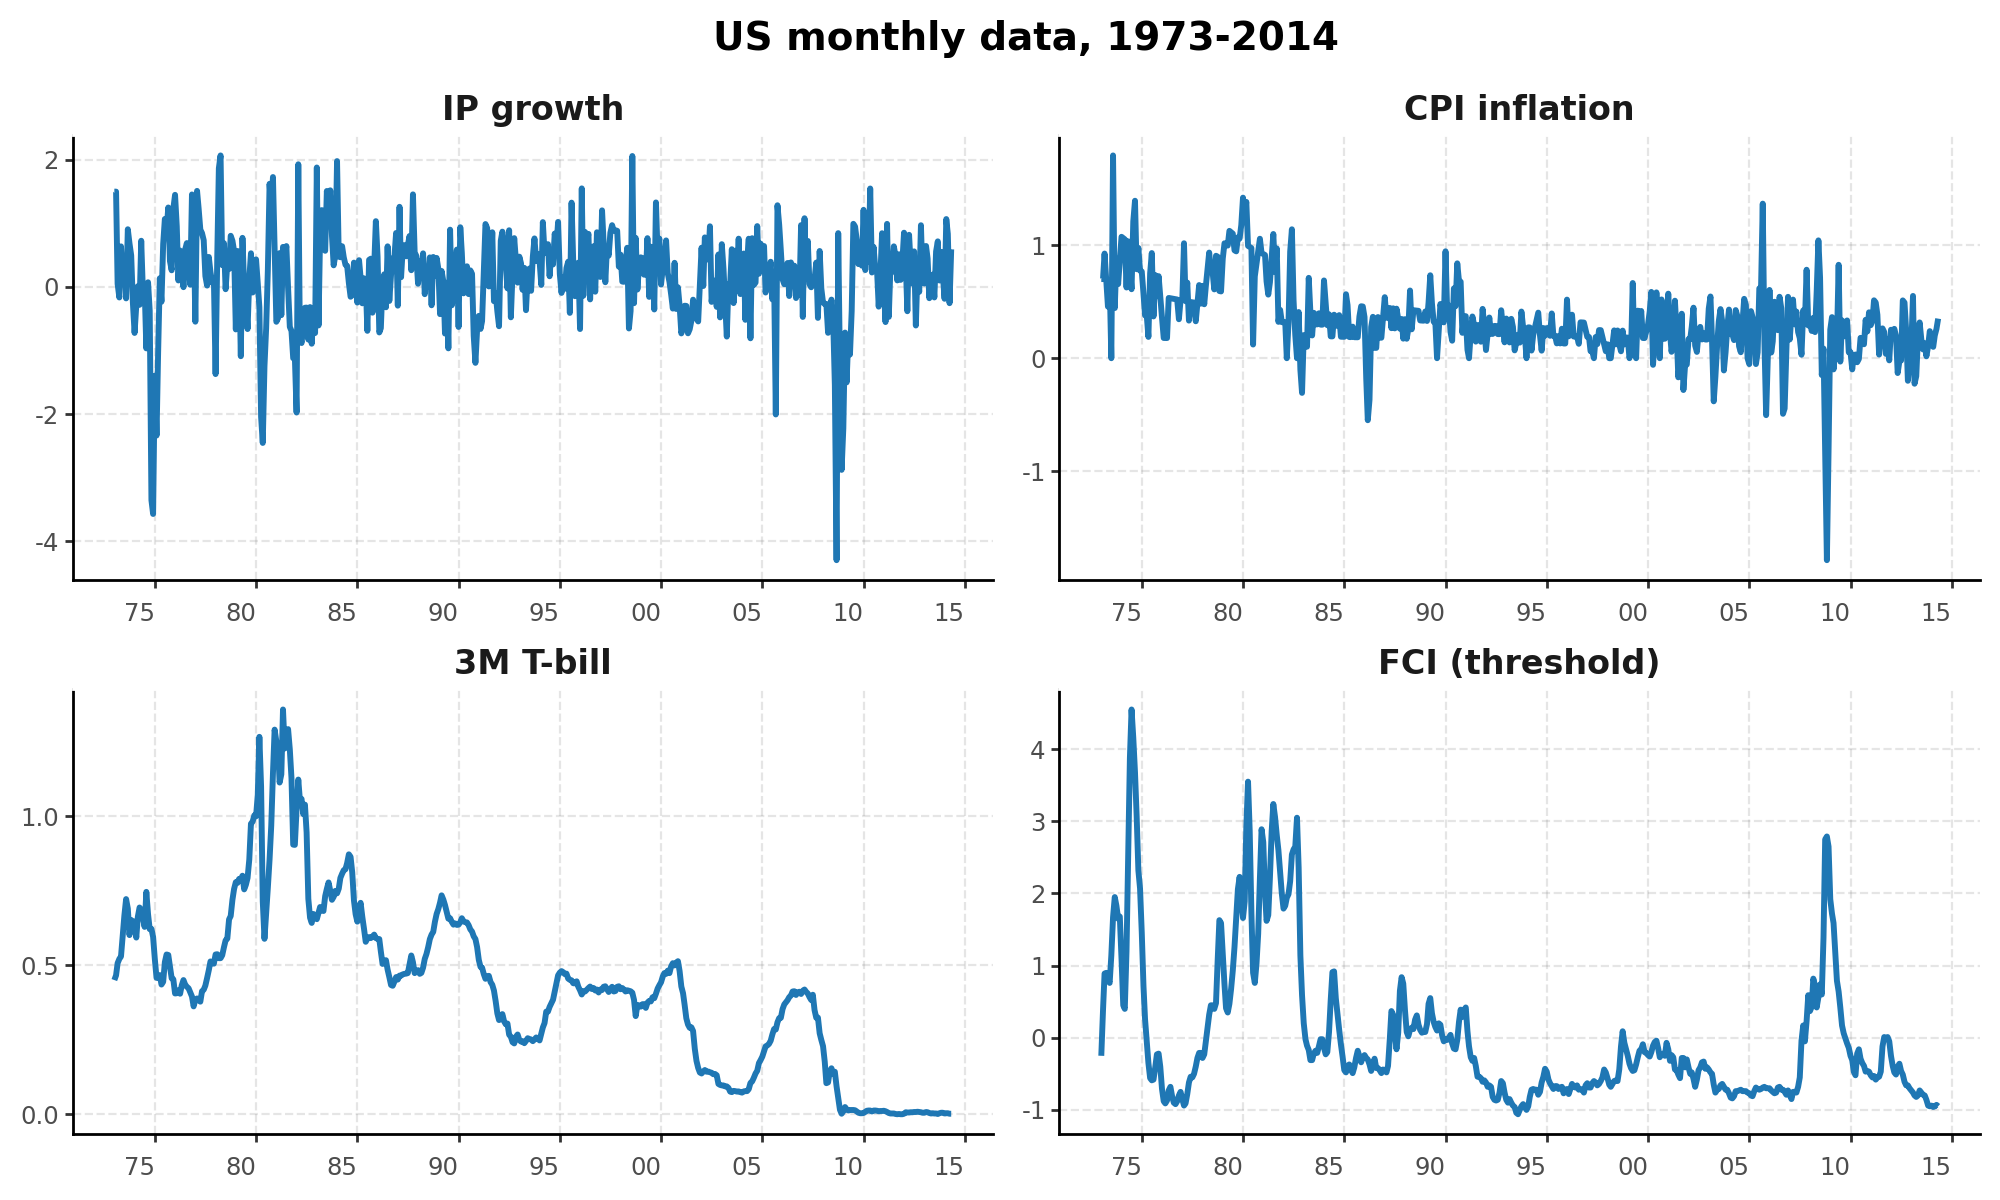

In [12]:
from MacroPy import generate_series_plot

generate_series_plot(
    df,
    series_titles=['IP growth', 'CPI inflation', '3M T-bill', 'FCI (threshold)'],
    title='US monthly data, 1973-2014',
)

## 2. Model setup

We use the authors' benchmark specification: $P=13$ lags, $J=3$ volatility-in-mean lags,
a maximum threshold delay of 12 months, and `fci` as the threshold variable. As in
`BayesianVAR`, **`post_draws` is the total number of draws including burn-in**, and
**`burnin` is the fraction to discard** (0.5 keeps the second half).

> The authors run 100,000 Gibbs iterations. The numbers below are deliberately modest so
> the notebook finishes in about a minute; raise `post_draws` for publication-quality bands.

In [13]:
from MacroPy import ThresholdVARSV

model = ThresholdVARSV(
    df,
    threshold_var='fci',
    lags=13,
    vol_lags=3,
    max_delay=12,
    post_draws=8000,   # total draws, including burn-in
    burnin=0.5,        # discard the first 50%
    hor=48,
    irf_1std=1,        # 1 s.d. structural shocks (as in BayesianVAR)
    seed=1234,
)
model.model_summary()


**MacroPy: A Toolbox for Bayesian Macroeconometric Analysis in Python**
Developed by [Renato Vassallo](https://www.linkedin.com/in/renatovassallo) - Institute for Economic Analysis (IAE-CSIC)
Version 0.1.6

---

**Model Specifications**
- **Model Type**: Threshold VAR with Stochastic Volatility (Alessandri & Mumtaz, 2019)
- **Endogenous Variables**: ip_growth, inflation, tbill_3m, fci
- **Threshold Variable**: fci
- **Number of Lags (P)**: 13
- **Volatility-in-Mean Lags (J)**: 3
- **Maximum Threshold Delay**: 12
- **Sample Period**: 1975-10-01 to 2014-05-01 (464 observations)
- **VAR Parameters (both regimes)**: 456

---

**Bayesian Estimation Settings**
- **Posterior Simulation**: Gibbs Sampling
- **Regimes**: 2 (calm / crisis), endogenous threshold and delay
- **Stochastic Volatility**: single common factor, AR(1) in logs
- **Total Draws**: 8000
- **Burn-in**: 4000 (50%)

---

**Impulse Response Details**
- **GIRF Horizon**: 48
- **Identification**: Generalized IRF (Koop, Pesaran & Potter, 1996)

---

**Model Equations**

$$

\begin{align*}
Z_t &= \Big(c_1 + \sum_{j=1}^{P} B_{1,j} Z_{t-j} + \sum_{j=0}^{J}\gamma_{1,j}\ln\lambda_{t-j} + \Omega_{1,t}^{1/2} e_t\Big)\,\tilde S_t \\
&\;+ \Big(c_2 + \sum_{j=1}^{P} B_{2,j} Z_{t-j} + \sum_{j=0}^{J}\gamma_{2,j}\ln\lambda_{t-j} + \Omega_{2,t}^{1/2} e_t\Big)(1-\tilde S_t) \\
\tilde S_t &= 1 \iff F_{t-d} \le Z^{*} \\
\Omega_{i,t} &= A_i^{-1} H_t A_i^{-1\prime}, \qquad H_t = \lambda_t \, \mathrm{diag}(s_1,\dots,s_N) \\
\ln \lambda_t &= \alpha + F \ln \lambda_{t-1} + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, Q)
\end{align*}

$$


## 3. Estimation

`sample_posterior` runs the Gibbs sampler with a progress bar (just like `BayesianVAR`).
A single chain shows a per-draw bar; for speed you can run several chains in parallel
with `model.sample_posterior(n_chains=4, n_jobs=-1)` (joblib), which shows a
chain-completion bar and pools the draws.

In [4]:
draws = model.sample_posterior(n_chains=1)
print('pooled posterior draws:', model.n_draws)

Sampling Posterior: 100%|██████████| 8000/8000 [01:01<00:00, 130.63it/s, acc=0.40, d=1, tar=0.655]

pooled posterior draws: 4000


## 4. The threshold and the delay

The paper reports a delay with **median of one month** and a 95% upper bound of two months,
i.e. the economy enters the crisis regime almost as soon as the threshold is breached.

In [5]:
model.threshold_summary()

,mean,p5,p50,p95
threshold (Z*),0.690253,0.628433,0.687891,0.75437
delay (d),1.251250,1.000000,1.000000,2.00000


In [6]:
vals, counts = np.unique(draws['delay'], return_counts=True)
pd.Series(counts / counts.sum(), index=vals, name='P(delay = d)').round(3)

1    0.753
2    0.243
3    0.004
Name: P(delay = d), dtype: float64

## 5. Financial regimes (paper Fig. 1)

`plot_regimes` is general (any threshold variable / dataset); here we relabel it for the
financial application. Gray bands mark months where the posterior probability of the crisis
regime exceeds 0.5 - concentrated, as in the paper, in the **early 1980s** and **2007-2009**.

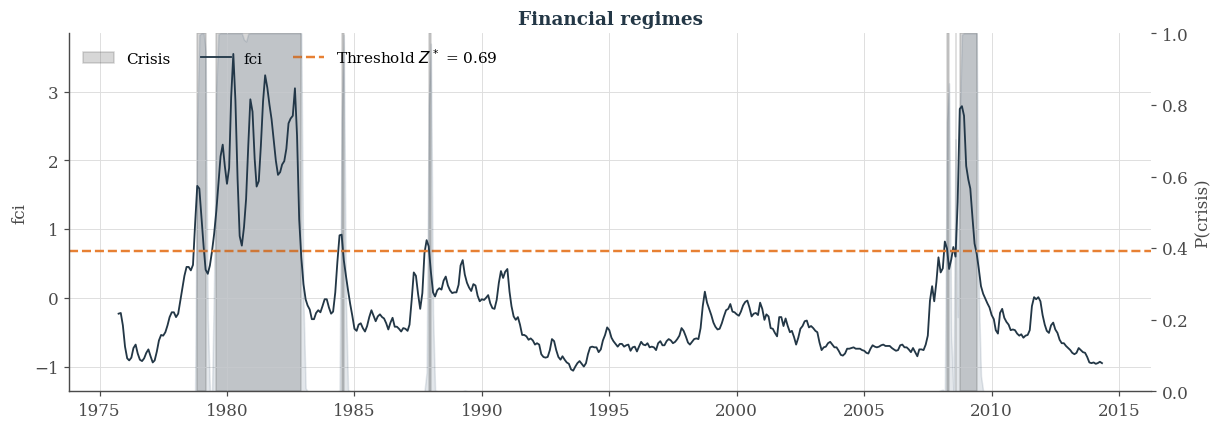

In [7]:
fig, ax = model.plot_regimes(
    regime_label='Crisis', prob_label='P(crisis)', title='Financial regimes',
)
plt.show()

## 6. Common stochastic volatility (paper Fig. 2)

The scalar factor $\lambda_t$ is the model's measure of aggregate uncertainty; it peaks
in the early 1980s and in 2008-09, mirroring the crisis regimes above.

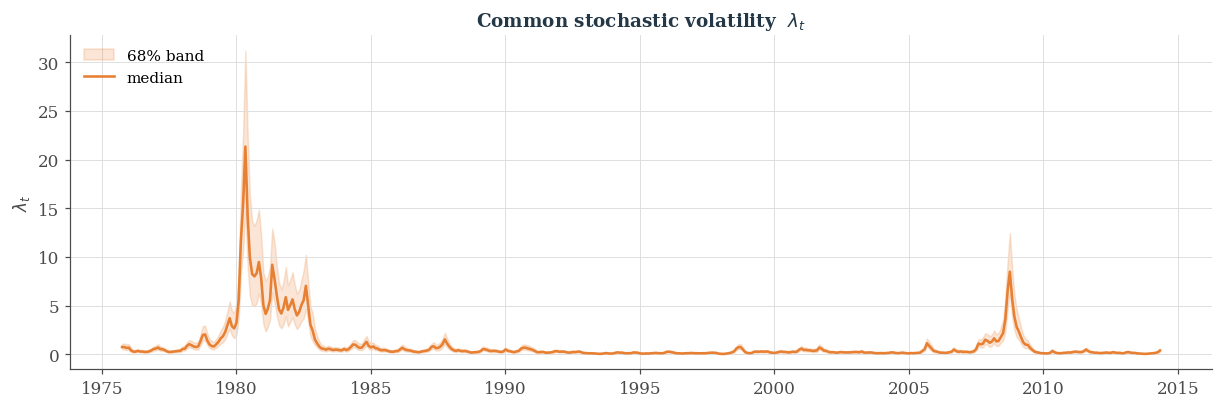

In [8]:
fig, ax = model.plot_volatility(cred=0.68)
plt.show()

## 7. Uncertainty shocks across regimes (paper Fig. 3)

Generalized impulse responses (Koop-Pesaran-Potter, 1996) to a **one-standard-deviation**
uncertainty shock $\eta_t$. `compute_irfs` returns responses for `regime1` (calm) and
`regime2` (crisis); `plot_irfs` overlays them with customizable labels. This is the central
result of the paper: **uncertainty shocks are strongly recessionary in distress, with an
output effect several times larger than in calm times** (and deflationary).

Computing IRFs: 100%|██████████| 400/400 [01:46<00:00,  3.77it/s]


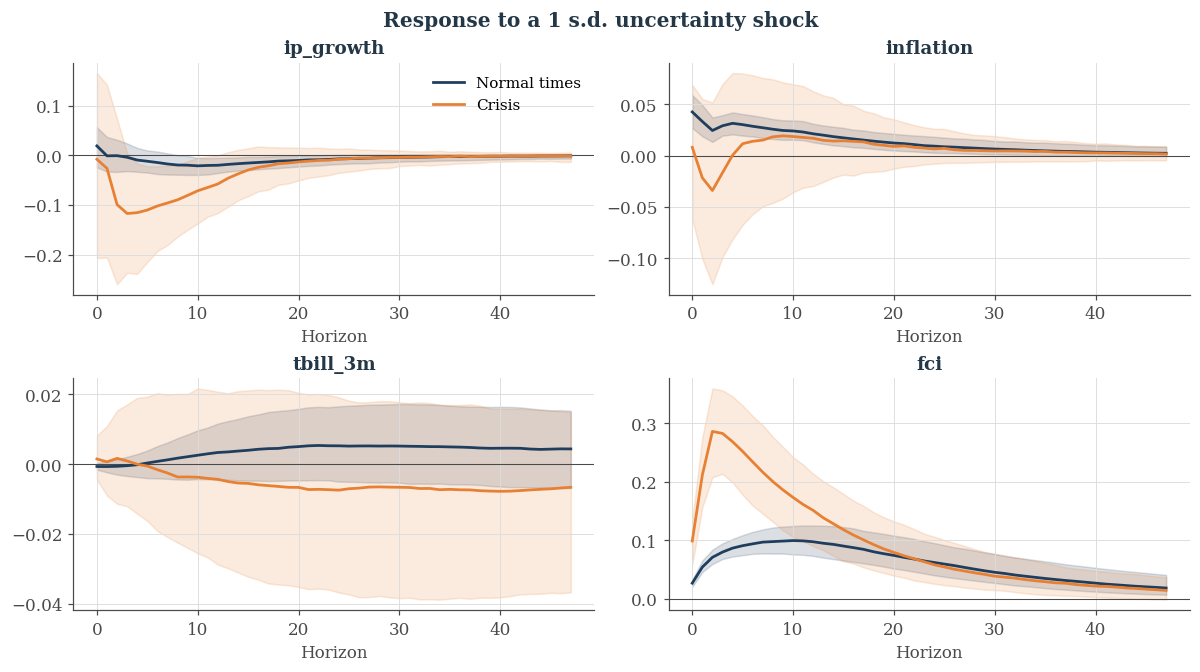

In [9]:
irf = model.compute_irfs(shock='uncertainty', reps=50, n_draws=400, n_jobs=-1)
fig, axes = model.plot_irfs(
    shock='uncertainty', cred=0.68,
    regime_labels=('Normal times', 'Crisis'),
    title='Response to a 1 s.d. uncertainty shock',
)
plt.show()

In [10]:
# Peak output (IP) response: calm (regime 1) vs crisis (regime 2)
ip_calm = np.median(irf['regime1']['uncertainty'][:, :, 0], axis=0)
ip_crisis = np.median(irf['regime2']['uncertainty'][:, :, 0], axis=0)
print(f'Peak IP fall  - normal : {ip_calm.min():+.3f}')
print(f'Peak IP fall  - crisis : {ip_crisis.min():+.3f}')
print(f'Crisis / normal ratio  : {ip_crisis.min() / ip_calm.min():.1f}x')

Peak IP fall  - normal : -0.021
Peak IP fall  - crisis : -0.117
Crisis / normal ratio  : 5.6x


## 8. Notes on replication

* The sampler is a faithful, vectorized port of the authors' MATLAB Gibbs sampler
  (regime VAR coefficients via a GLS transform + Minnesota dummies, the contemporaneous
  matrices $A_i$, loadings $s_j$, volatility AR parameters, the $\lambda_t$ path via
  Jacquier-Polson-Rossi, the threshold via random-walk Metropolis and the delay from its
  multinomial conditional).
* `post_draws` / `burnin` and `irf_1std` follow the `BayesianVAR` conventions.
* GIRFs use **common random numbers** across the baseline and shocked simulations, a
  variance reduction that leaves the expected response unchanged but needs far fewer Monte
  Carlo paths than independent draws.
* For results matching the published bands, raise `post_draws` toward the tens of thousands
  (use `n_chains>1` to parallelize) and `n_draws`/`reps` in `compute_irfs`.